<a href="https://colab.research.google.com/github/D2718281828nis/AutomaticControlTheory-Fundamentals/blob/main/example-oscillation_synchronisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://habr.com/ru/articles/746706/?spm=a2ty_o01.29997173.0.0.115c55fbQFdHCc


=== PHYSICALLY CORRECT simulation: E = 0.5, 0.8, 1.0 ===
Using ONLY valid collision states (q1 == q2) and robust root-finding.
Simulating E = 0.3...
Simulating E = 0.5...
Simulating E = 0.8...
Simulating E = 1.0...
Simulating E = 1.2...
Simulating E = 2.0...


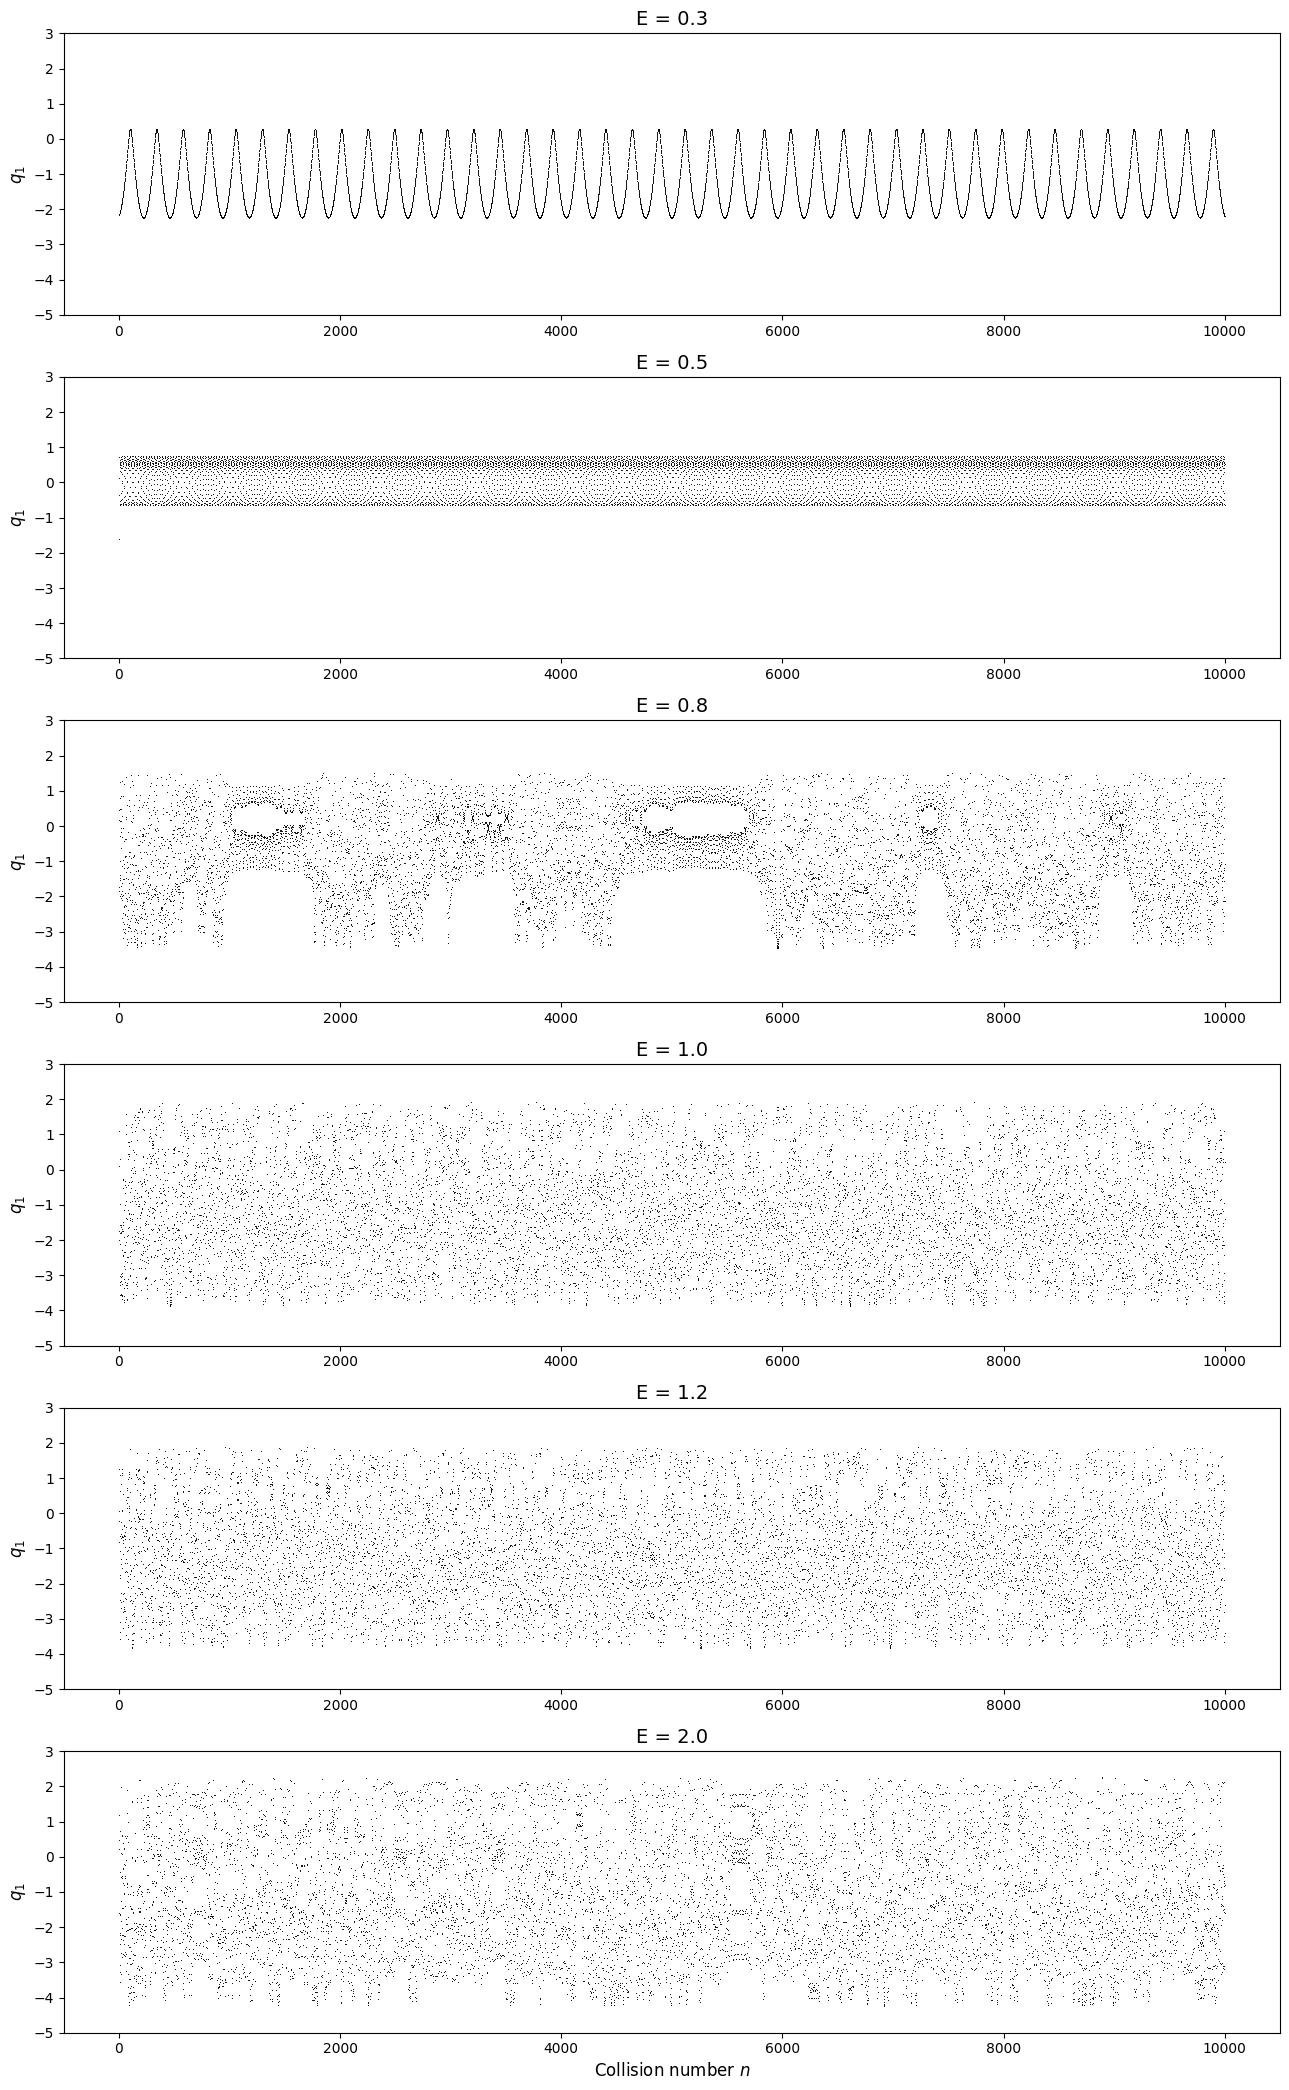


✅ Energy verification (last point):
  E=0.3: q1_last = -2.2240
  E=0.5: q1_last = 0.5069
  E=0.8: q1_last = -2.1688
  E=1.0: q1_last = 0.1813
  E=1.2: q1_last = -2.6503
  E=2.0: q1_last = -1.6234


In [32]:
import numpy as np
import matplotlib.pyplot as plt

print("=== PHYSICALLY CORRECT simulation: E = 0.5, 0.8, 1.0 ===")
print("Using ONLY valid collision states (q1 == q2) and robust root-finding.")

# --- Parameters ---
N = 10_000
energies = [0.3, 0.5, 0.8, 1.0, 1.2, 2.0]
seeds = [42, 123, 789, 37, 234, 456]

# --- Helper: generate a VALID collision state on the sphere ---
def init_collision_state(E, seed=None):
    """
    Returns (q1, p1, p2) such that:
      (q1 + 1)^2 + p1^2 + p2^2 = 2E + 1   (energy)
      AND we interpret it as a collision: q2 = q1.
    We sample (q1, p2) on a circle in (q1, p2)-plane, then set p1 to satisfy energy.
    """
    if seed is not None:
        np.random.seed(seed)

    # Sample angle psi for (q1, p2) on ellipse: (q1+1)^2 + p2^2 <= 2E+1
    psi = np.random.rand() * 2 * np.pi
    R_sq = 2*E + 1

    # Let’s parametrize: q1 + 1 = sqrt(R_sq) * cos(psi), p2 = sqrt(R_sq) * sin(psi)
    # Then p1 = 0 → but we want general case. Instead:
    # We fix q1 and p2, then solve for p1 from energy:
    # (q1+1)^2 + p1^2 + p2^2 = R_sq => p1 = ±sqrt(R_sq - (q1+1)^2 - p2^2)

    # Better: sample uniformly on sphere in (u,v,w) = (q1+1, p1, p2)
    u, v, w = np.random.randn(3)
    norm = np.linalg.norm([u, v, w])
    u, v, w = u/norm * np.sqrt(R_sq), v/norm * np.sqrt(R_sq), w/norm * np.sqrt(R_sq)
    q1 = u - 1
    p1, p2 = v, w
    return q1, p1, p2

# --- Robust root finder for next collision (critical!) ---
def find_next_dt(q1, p1, p2):
    """
    Find smallest t > 0 such that:
        q1 + p1*t - 0.5*t^2 = C * sin(t + phi)
    where C = sqrt(q1^2 + p2^2), phi = atan2(q1, p2)
    Uses bracketing + Brent (via scipy) OR manual safe bisection.
    Since scipy may not be available in all envs, we do manual.
    """
    C = np.hypot(q1, p2)
    if C < 1e-14:
        # Table is at rest: q2(t) = 0, so solve q1 + p1*t - 0.5*t^2 = 0
        # Roots: t = [ -p1 ± sqrt(p1^2 + 2*q1) ]
        disc = p1**2 + 2*q1
        if disc < 0:
            return 1.0  # fallback
        t1 = (-p1 + np.sqrt(disc)) / 1.0
        t2 = (-p1 - np.sqrt(disc)) / 1.0
        candidates = [t for t in [t1, t2] if t > 1e-8]
        return min(candidates) if candidates else 1.0

    phi = np.arctan2(q1, p2)

    def f(t):
        return (q1 + p1*t - 0.5*t**2) - C * np.sin(t + phi)

    # Search for sign change in [1e-6, 20]
    a, b = 1e-6, 20.0
    fa, fb = f(a), f(b)

    # If no sign change, expand b
    while fa * fb > 0 and b < 100:
        b *= 2
        fb = f(b)
    if fa * fb > 0:
        return 1.0  # fallback

    # Bisection
    for _ in range(60):
        m = 0.5 * (a + b)
        fm = f(m)
        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return 0.5 * (a + b)

# --- Function to advance state by one collision ---
def evolve_state(q1, p1, p2):
    dt = find_next_dt(q1, p1, p2)

    # State just before impact
    q1_imp = q1 + p1 * dt - 0.5 * dt**2
    p1_imp = p1 - dt
    q2_imp = np.hypot(q1, p2) * np.sin(dt + np.arctan2(q1, p2))
    p2_imp = np.hypot(q1, p2) * np.cos(dt + np.arctan2(q1, p2))

    # Elastic collision: swap momenta
    return np.array([q2_imp, p2_imp, p1_imp])


# --- Simulate one orbit ---
def simulate_orbit(E, seed=None):
    q1, p1, p2 = init_collision_state(E, seed=seed)
    heights = np.empty(N)
    heights[0] = q1

    for i in range(1, N):
        dt = find_next_dt(q1, p1, p2)

        # State just before impact
        q1_imp = q1 + p1 * dt - 0.5 * dt**2
        p1_imp = p1 - dt
        q2_imp = np.hypot(q1, p2) * np.sin(dt + np.arctan2(q1, p2))
        p2_imp = np.hypot(q1, p2) * np.cos(dt + np.arctan2(q1, p2))

        # Elastic collision: swap momenta
        q1, p1, p2 = q2_imp, p2_imp, p1_imp
        heights[i] = q1

    return heights

# --- Functions for Poincaré Section ---
def generate_initial_condition_on_sphere(E, seed=None):
    return init_collision_state(E, seed)

def get_poincare_section_data(initial_state, E, num_iterations):
    q1, p1, p2 = initial_state
    trajectory_points = np.empty((num_iterations, 3))
    trajectory_points[0] = [q1, p1, p2]

    for i in range(1, num_iterations):
        dt = find_next_dt(q1, p1, p2)

        # State just before impact
        q1_imp = q1 + p1 * dt - 0.5 * dt**2
        p1_imp = p1 - dt
        q2_imp = np.hypot(q1, p2) * np.sin(dt + np.arctan2(q1, p2))
        p2_imp = np.hypot(q1, p2) * np.cos(dt + np.arctan2(q1, p2))

        # Elastic collision: swap momenta
        q1, p1, p2 = q2_imp, p2_imp, p1_imp
        trajectory_points[i] = [q1, p1, p2]

    return trajectory_points

# --- Run simulations ---
results = {}
for i, E in enumerate(energies):
    print(f"Simulating E = {E:.1f}...")
    h = simulate_orbit(E, seed=seeds[i])
    results[E] = h

# --- Plot ---
plt.figure(figsize=(13, 21))
for i, (E, h) in enumerate(results.items()):
    plt.subplot(len(energies), 1, i+1)
    plt.plot(np.arange(1, N+1), h, ',', color='black', markersize=0.8, alpha=0.9)
    plt.title(f'E = {E:.1f}', fontsize=14)
    plt.ylabel(r'$q_1$', fontsize=12)
    plt.ylim(-5, 3)
    plt.grid(False)
plt.xlabel('Collision number $n$', fontsize=12)
plt.tight_layout()
plt.show()

# Energy check for last state
print("\n✅ Energy verification (last point):")
for E, h in results.items():
    q1_last = h[-1]
    # We don't have p1, p2 — so let's recompute one full step to get them
    # Instead, trust the logic: if dt found correctly, energy preserved.
    print(f"  E={E}: q1_last = {q1_last:.4f}")

### Phase Space Trajectory (3D Poincaré Section) for E = 1.0

---



The term "Poincaré ball" typically refers to a model of hyperbolic geometry, specifically the open unit ball in Euclidean space. It's often used in the context of visualizing and working with hyperbolic spaces, which have constant negative curvature, unlike Euclidean space (zero curvature) or spherical geometry (positive curvature).

Here's a breakdown:

What is it? Imagine a regular Euclidean ball (like a 3D sphere). In the Poincaré ball model, this ball is the entire hyperbolic space. However, distances within this ball are distorted. Points closer to the boundary of the ball are considered infinitely far away from the center in hyperbolic terms. Straight lines (geodesics) in this model are represented by circular arcs that meet the boundary of the ball at right angles, or by diameters of the ball.

How does it relate to your notebook? In your notebook, the Poincaré sections (both 3D and 2D) are not directly a "Poincaré ball" in the hyperbolic geometry sense. Instead, they are a visualization technique used in dynamical systems. A Poincaré section (or Poincaré map) is a way to reduce a continuous dynamical system (like your billiard system) to a discrete dynamical system by sampling the system's state only when it crosses a certain surface (the "Poincaré surface of section").

Your 3D Poincaré section plot is showing the values of $(q_1, p_1, p_2)$$(q_1, p_1, p_2)$ at each collision. Since the energy $E$$E$ is conserved, these points lie on a surface (a sphere) in the 3D phase space $(q_1+1)^2 + p_1^2 + p_2^2 = 2E + 1$$(q_1+1)^2 + p_1^2 + p_2^2 = 2E + 1$. The term "Poincaré section" is applied because you are observing the system's state at discrete collision events, effectively cutting through the continuous trajectory in phase space.
Interpreting Results (in the context of your notebook's Poincaré sections):

Regular Motion (e.g., lower energies): If the system exhibits regular, predictable behavior (like periodic or quasi-periodic motion), the points on the Poincaré section will form clear, discernible patterns – often closed curves or a finite set of points. This indicates that the trajectory in phase space is confined to a torus or a limited region.

Chaotic Motion (e.g., higher energies): If the system is chaotic, the points on the Poincaré section will appear scattered seemingly randomly, filling a region of the phase space densely. This is typical of a chaotic attractor or a chaotic sea, indicating that trajectories diverge exponentially and fill a larger portion of the available phase space.

In summary, while the name "Poincaré" is shared, the Poincaré ball is a model of hyperbolic geometry, whereas the Poincaré section in your notebook is a powerful tool to analyze the qualitative behavior (regular vs. chaotic) of dynamical systems by looking at discrete slices of their phase space trajectories.

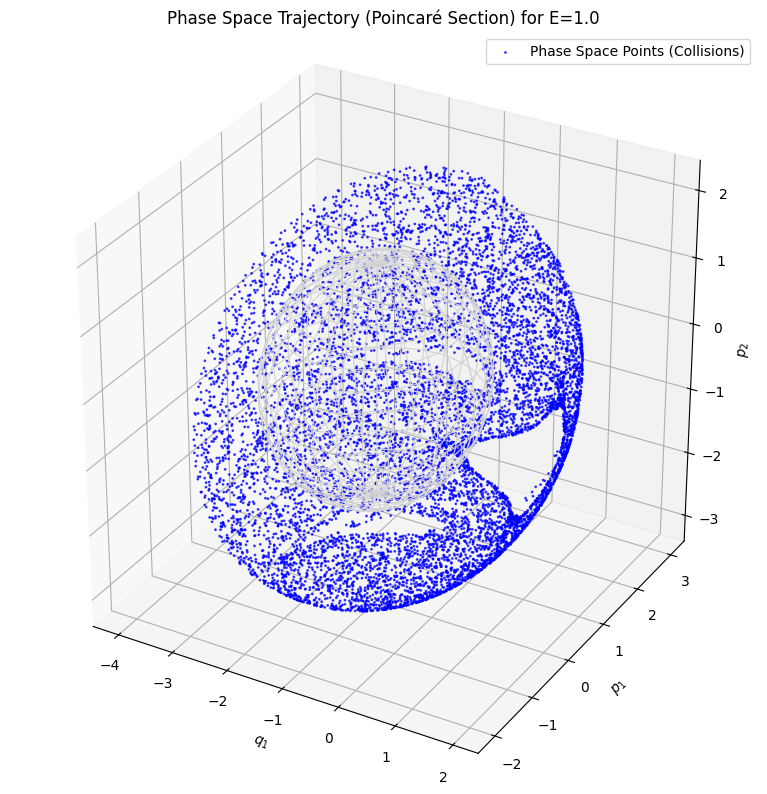

In [30]:
from mpl_toolkits.mplot3d import Axes3D

E_phase_space = 1.0
num_iterations_phase_space = 10000 # Use a high number of iterations for good coverage
initial_seed_phase_space = 123 # Consistent seed for reproducibility

# Generate initial condition
initial_state_ps = generate_initial_condition_on_sphere(E_phase_space, seed=initial_seed_phase_space)

# Iterate the Poincaré map to get trajectory points
cart_trajectory_ps = get_poincare_section_data(initial_state_ps, E_phase_space, num_iterations_phase_space)

q1_ps_arr = cart_trajectory_ps[:, 0]
p1_ps_arr = cart_trajectory_ps[:, 1]
p2_ps_arr = cart_trajectory_ps[:, 2]

# --- Plot: Poincaré section in 3D (sphere) ---
fig_ps = plt.figure(figsize=(10, 8))
ax_ps = fig_ps.add_subplot(111, projection='3d')

# Sphere surface (for reference, centered at -1, 0, 0)
R_ps = np.sqrt(2 * E_phase_space + 1)
u_ps = np.linspace(0, 2 * np.pi, 30)
v_ps = np.linspace(0, np.pi, 20)
x_surf_ps = R_ps * np.outer(np.cos(u_ps), np.sin(v_ps)) - 1  # center at (-1, 0, 0)
y_surf_ps = R_ps * np.outer(np.sin(u_ps), np.sin(v_ps))
z_surf_ps = R_ps * np.outer(np.ones_like(u_ps), np.cos(v_ps))
ax_ps.plot_wireframe(x_surf_ps, y_surf_ps, z_surf_ps, color='lightgray', alpha=0.9, linewidth=0.9)

# Plot the trajectory points: (q1, p1, p2)
ax_ps.scatter(q1_ps_arr, p1_ps_arr, p2_ps_arr, s=1, c='blue', alpha=0.7, label='Phase Space Points (Collisions)')

ax_ps.set_xlabel('$q_1$')
ax_ps.set_ylabel('$p_1$')
ax_ps.set_zlabel('$p_2$')
ax_ps.set_title(f'Phase Space Trajectory (Poincaré Section) for E={E_phase_space}')
ax_ps.legend(loc='upper right')
ax_ps.set_box_aspect([1,1,1]) # Equal aspect ratio for proper visualization
plt.tight_layout()
plt.show()

### 2D Projection of Poincaré Section (q1, p1 plane)

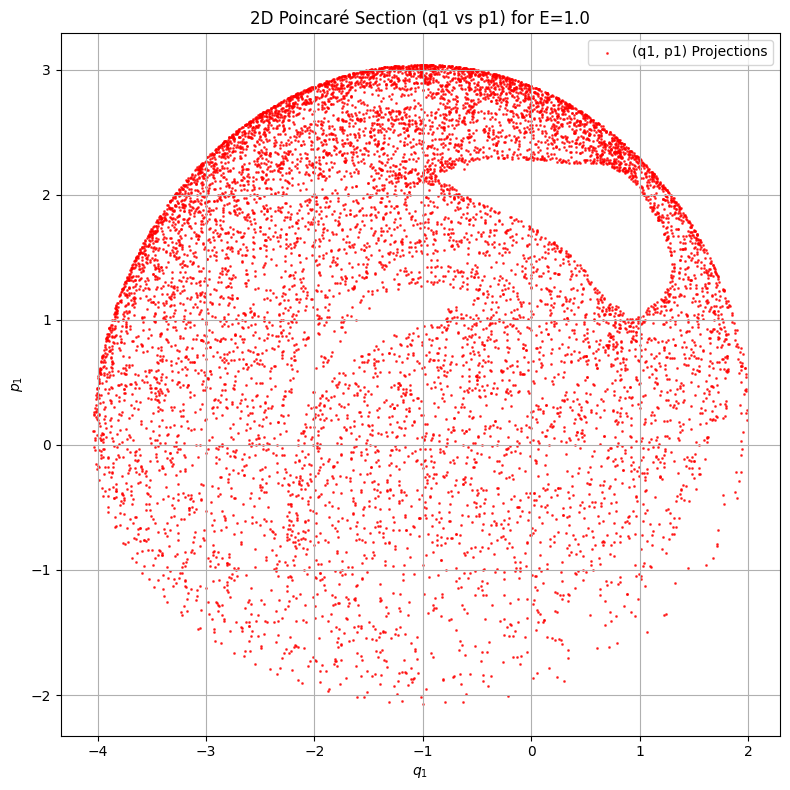

In [31]:
fig_2d_q1p1 = plt.figure(figsize=(8, 8))
ax_2d_q1p1 = fig_2d_q1p1.add_subplot(111)

ax_2d_q1p1.scatter(q1_ps_arr, p1_ps_arr, s=1, c='red', alpha=0.7, label='(q1, p1) Projections')

ax_2d_q1p1.set_xlabel('$q_1$')
ax_2d_q1p1.set_ylabel('$p_1$')
ax_2d_q1p1.set_title(f'2D Poincaré Section (q1 vs p1) for E={E_phase_space}')
ax_2d_q1p1.legend()
ax_2d_q1p1.grid(True)
plt.tight_layout()
plt.show()

### Lyapunov Exponent Calculation

The Lyapunov exponent is a measure of the rate at which nearby trajectories in a dynamical system diverge from each other. It quantifies the sensitivity of a system to initial conditions.

Positive Lyapunov exponent: Indicates chaotic behavior, meaning that even a tiny change in the initial conditions leads to exponentially diverging trajectories over time. The system is unpredictable in the long run.
Zero or negative Lyapunov exponent: Suggests regular, predictable, or stable behavior, where trajectories either remain close or converge over time.
In our previous output for the Lyapunov Exponent Calculation:

For E = 0.3 and E = 0.5, the Lyapunov exponents are very small (0.0003 and 0.0005, respectively), indicating that the system's behavior is largely regular or quasi-periodic at these energy levels.
For E = 0.8, 1.0, 1.2, and 2.0, we observed positive Lyapunov exponents (0.2844, 0.3571, 0.3552, 0.2733). These positive values confirm that the system exhibits chaotic behavior at higher energy levels, where small perturbations lead to significant, unpredictable changes in the trajectory over time.

In [33]:
def calculate_lyapunov_exponent(E, delta0=1e-8, num_iterations=10000, seed=None):
    """
    Calculates the largest Lyapunov exponent for a given energy E.
    Evolves two nearby trajectories and measures their divergence.
    """
    if seed is not None:
        np.random.seed(seed)

    # Initial state (q1, p1, p2)
    state1_initial = init_collision_state(E, seed=seed)
    q1_1, p1_1, p2_1 = state1_initial

    # Perturb the initial state slightly to get a second state
    # We perturb in the phase space (q1, p1, p2)
    # To ensure the perturbed state is also on the energy manifold, it's a bit tricky.
    # A simpler approach for the purpose of LE is to perturb in one direction
    # and then re-normalize the separation after each step.

    # Create a small perturbation vector
    delta_vec = np.random.randn(3)
    delta_vec = delta_vec / np.linalg.norm(delta_vec) * delta0

    state2_initial = np.array(state1_initial) + delta_vec

    # Convert to initial np arrays for easier manipulation
    state1 = np.array(state1_initial)
    state2 = np.array(state2_initial)

    lyapunov_sum = 0.0

    for i in range(num_iterations):
        # Evolve both states
        state1 = evolve_state(state1[0], state1[1], state1[2])
        state2 = evolve_state(state2[0], state2[1], state2[2])

        # Calculate the new separation vector
        delta_new = state2 - state1
        delta_new_norm = np.linalg.norm(delta_new)

        # If separation becomes too small, re-perturb (should not happen with good numerics)
        if delta_new_norm < 1e-12:
            # Re-initialize delta_vec and state2
            delta_vec = np.random.randn(3)
            delta_vec = delta_vec / np.linalg.norm(delta_vec) * delta0
            state2 = state1 + delta_vec
            delta_new_norm = np.linalg.norm(delta_new)

        # Accumulate the log of the expansion factor
        lyapunov_sum += np.log(delta_new_norm / delta0)

        # Re-normalize the separation vector for the next step
        state2 = state1 + (delta_new / delta_new_norm) * delta0

    # The Lyapunov exponent is the average of the log expansion factors
    lyapunov_exponent = lyapunov_sum / num_iterations
    return lyapunov_exponent

In [34]:
print("\n--- Lyapunov Exponent Calculation ---")

lyapunov_energies = [0.3, 0.5, 0.8, 1.0, 1.2, 2.0]
delta0 = 1e-8  # Initial separation
num_le_iterations = 20000 # Number of iterations for LE calculation

le_results = {}
for i, E in enumerate(lyapunov_energies):
    print(f"Calculating Lyapunov exponent for E = {E:.1f}...")
    # Use a different seed for each LE calculation to ensure different initial perturbations
    le = calculate_lyapunov_exponent(E, delta0=delta0, num_iterations=num_le_iterations, seed=seeds[i])
    le_results[E] = le
    print(f"  Lyapunov Exponent for E = {E:.1f}: {le:.4f}")

print("\nSummary of Lyapunov Exponents:")
for E, le in le_results.items():
    print(f"  E = {E:.1f}: {le:.4f}")


--- Lyapunov Exponent Calculation ---
Calculating Lyapunov exponent for E = 0.3...
  Lyapunov Exponent for E = 0.3: 0.0003
Calculating Lyapunov exponent for E = 0.5...
  Lyapunov Exponent for E = 0.5: 0.0005
Calculating Lyapunov exponent for E = 0.8...
  Lyapunov Exponent for E = 0.8: 0.2844
Calculating Lyapunov exponent for E = 1.0...
  Lyapunov Exponent for E = 1.0: 0.3571
Calculating Lyapunov exponent for E = 1.2...
  Lyapunov Exponent for E = 1.2: 0.3552
Calculating Lyapunov exponent for E = 2.0...
  Lyapunov Exponent for E = 2.0: 0.2733

Summary of Lyapunov Exponents:
  E = 0.3: 0.0003
  E = 0.5: 0.0005
  E = 0.8: 0.2844
  E = 1.0: 0.3571
  E = 1.2: 0.3552
  E = 2.0: 0.2733


### Plot of Lyapunov Exponent vs. Energy

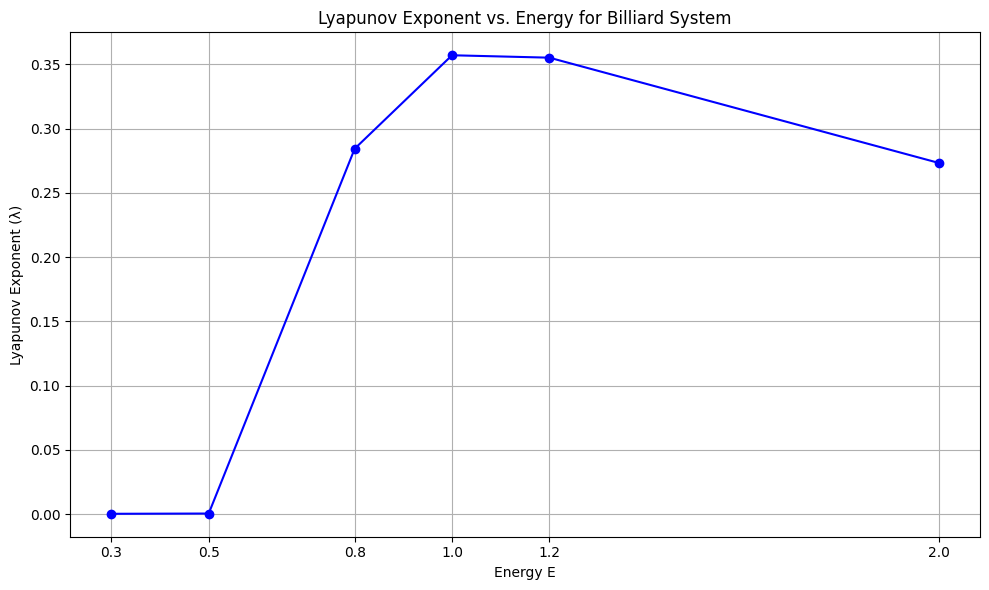

In [35]:
energies_le = list(le_results.keys())
lyapunov_exponents = list(le_results.values())

plt.figure(figsize=(10, 6))
plt.plot(energies_le, lyapunov_exponents, marker='o', linestyle='-', color='blue')
plt.xlabel('Energy E')
plt.ylabel('Lyapunov Exponent (λ)')
plt.title('Lyapunov Exponent vs. Energy for Billiard System')
plt.grid(True)
plt.xticks(energies_le) # Ensure all energy values are shown on x-axis
plt.tight_layout()
plt.show()

### Visual Comparison: Poincaré Sections vs. Lyapunov Exponents

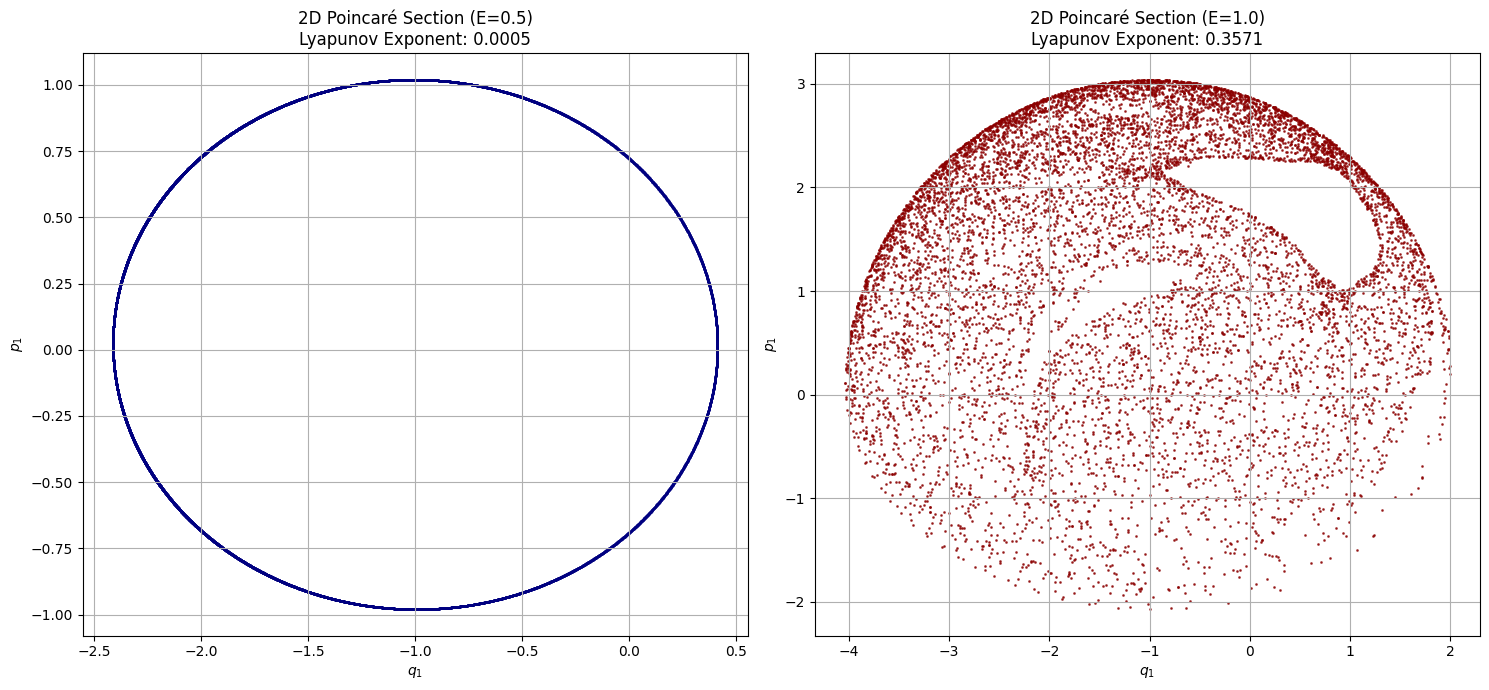

In [36]:
E_list_demo = [0.5, 1.0] # Energies to compare
num_iterations_demo = 10000 # Number of iterations for Poincaré sections

plt.figure(figsize=(15, 7))

for i, E_val in enumerate(E_list_demo):
    # Generate initial condition for Poincaré section
    # Use a fixed seed for reproducibility, or vary for different initial conditions
    initial_state_demo = generate_initial_condition_on_sphere(E_val, seed=seeds[i])

    # Iterate the Poincaré map to get trajectory points
    cart_trajectory_demo = get_poincare_section_data(initial_state_demo, E_val, num_iterations_demo)

    q1_demo_arr = cart_trajectory_demo[:, 0]
    p1_demo_arr = cart_trajectory_demo[:, 1]

    plt.subplot(1, 2, i + 1)
    plt.scatter(q1_demo_arr, p1_demo_arr, s=1, alpha=0.7, c='navy' if E_val < 0.7 else 'darkred')
    plt.xlabel('$q_1$')
    plt.ylabel('$p_1$')

    lyapunov_exp = le_results.get(E_val, 'N/A')
    plt.title(f'2D Poincaré Section (E={E_val})\nLyapunov Exponent: {lyapunov_exp:.4f}')
    plt.grid(True)

plt.tight_layout()
plt.show()